In [1]:
import numpy as np
import pandas as pd

import sys
import os
sys.path.append(os.path.abspath(".."))
import utils.plot_utils as pu

In [2]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data', 
                 header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X = df.iloc[:, 2:].values
y = df.iloc[:, 1].values

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y = le.fit_transform(y)
print(np.unique(y))
print(le.classes_)
print(le.transform(['M','B']))

[0 1]
['B' 'M']
[1 0]


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [5]:
# Pipeline in sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

pipe_lr = make_pipeline(StandardScaler(), PCA(n_components=2), LogisticRegression())
pipe_lr.fit(X_train, y_train)

y_pred = pipe_lr.predict(X_test)
test_accuracy = pipe_lr.score(X_test, y_test)
print(f"Pipeline Accuracy : {test_accuracy: 0.3f}")

Pipeline Accuracy :  0.956


In [6]:
# k-fold cv in sklearn
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10)
kfold = skf.split(X_train, y_train)
scores = []

for k, (train_idx, test_idx) in enumerate(kfold):
    pipe_lr.fit(X_train[train_idx], y_train[train_idx])
    score = pipe_lr.score(X_train[test_idx], y_train[test_idx])
    scores.append(score)
    print(f"Fold No. {k+1}: Class Distribution is {np.bincount(y_train[train_idx])}, Score is {score: 0.3f}")

print(f"The CV Accuracy is {np.mean(scores): 0.3f} with +/- {np.std(scores): 0.3f}")


Fold No. 1: Class Distribution is [256 153], Score is  0.935
Fold No. 2: Class Distribution is [256 153], Score is  0.935
Fold No. 3: Class Distribution is [256 153], Score is  0.957
Fold No. 4: Class Distribution is [256 153], Score is  0.957
Fold No. 5: Class Distribution is [256 153], Score is  0.935
Fold No. 6: Class Distribution is [257 153], Score is  0.956
Fold No. 7: Class Distribution is [257 153], Score is  0.978
Fold No. 8: Class Distribution is [257 153], Score is  0.933
Fold No. 9: Class Distribution is [257 153], Score is  0.956
Fold No. 10: Class Distribution is [257 153], Score is  0.956
The CV Accuracy is  0.950 with +/-  0.014


In [7]:
# Cross Validation in sklearn - More concise code
from sklearn.model_selection import cross_val_score
scores = cross_val_score(pipe_lr, X_train, y_train, cv=10, n_jobs=1)

print(f"Accuracy Scores for each fold : {scores}")
print(f"Overall CV Accuracy: {np.mean(scores): 0.3f} +/- {np.std(scores): 0.3f}")

Accuracy Scores for each fold : [0.93478261 0.93478261 0.95652174 0.95652174 0.93478261 0.95555556
 0.97777778 0.93333333 0.95555556 0.95555556]
Overall CV Accuracy:  0.950 +/-  0.014


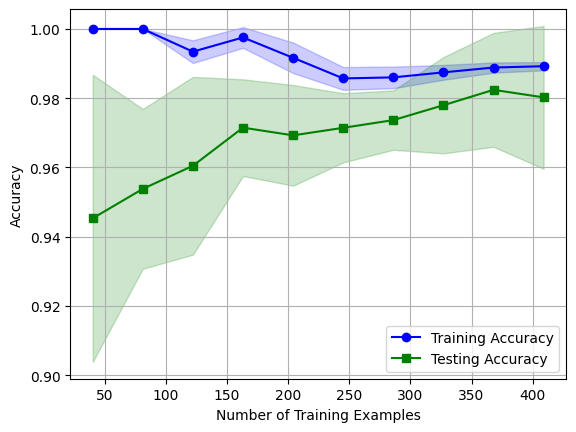

In [ ]:
# Learning Curves in sklearn
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

pipe_lr = make_pipeline(StandardScaler(), LogisticRegression(l1_ratio=0, max_iter=10000))
train_size, train_score, test_score = learning_curve(estimator=pipe_lr, X=X_train, y=y_train, 
                                                     train_sizes=np.linspace(0.1,1,10),
                                                     cv=10, n_jobs=1, random_state=1)

train_mean = np.mean(train_score, axis=1)
train_std = np.std(train_score, axis=1)
test_mean = np.mean(test_score, axis=1)
test_std = np.std(test_score, axis=1)

plt.plot(train_size, train_mean, color='blue', marker='o', label='Training Accuracy')
plt.fill_between(train_size, train_mean+train_std, train_mean-train_std, color='blue', alpha=0.2)
plt.plot(train_size, test_mean, color='green', marker='s', label='Testing Accuracy')
plt.fill_between(train_size, test_mean+test_std, test_mean-test_std, color='green', alpha=0.2)

plt.xlabel("Number of Training Examples")
plt.ylabel("Accuracy")
# plt.ylim([0.85, 1.03])
plt.grid()
plt.legend(loc='lower right')
plt.show()

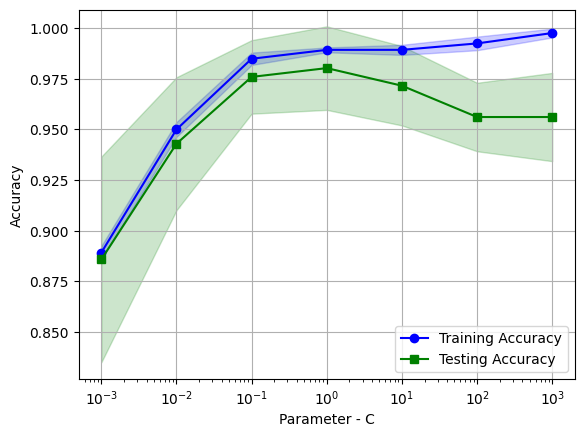

In [27]:
# Training Curves in sklearn
from sklearn.model_selection import validation_curve
param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
train_score, test_score = validation_curve(estimator=pipe_lr, X=X_train, y=y_train, 
                                           param_name='logisticregression__C',
                                           param_range=param_range, cv=10)

train_mean = np.mean(train_score, axis=1)
train_std = np.std(train_score, axis=1)
test_mean = np.mean(test_score, axis=1)
test_std = np.std(test_score, axis=1)

plt.plot(param_range, train_mean, color='blue', marker='o', label='Training Accuracy')
plt.plot(param_range, test_mean, color='green', marker='s', label='Testing Accuracy')
plt.fill_between(param_range, train_mean+train_std, train_mean-train_std, color='blue', alpha=0.2)
plt.fill_between(param_range, test_mean+test_std, test_mean-test_std, color='green', alpha=0.2)

plt.xscale('log')
plt.grid()
plt.legend(loc = 'lower right')
plt.xlabel("Parameter - C")
plt.ylabel("Accuracy")
plt.show()

In [36]:
# GridSearch CV in sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

pipe_svm = make_pipeline(StandardScaler(), SVC(random_state=1))
param_range = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
param_grid = [{'svc__C': param_range, 'svc__kernel': ['linear']},
              {'svc__C': param_range, 'svc__gamma': param_range, 'svc__kernel': ['rbf']}]

gs = GridSearchCV(estimator=pipe_svm, param_grid=param_grid, refit=True, cv=10, n_jobs=-1, scoring='accuracy')
gs.fit(X_train, y_train)

print(f"Best Score found by GridCV: {gs.best_score_: 0.3f}")
print(f"Best hyperparameter values as per GridCV: {gs.best_params_}")

# Selecting the best model
# 1. refit = True in during gridcv initialization. Refer the code above
# 2. Choose the best model obtained in GridCV. Refer the code below

model_best = gs.best_estimator_
model_best.fit(X_train, y_train)

print(f"Test Accuracy : {model_best.score(X_test, y_test): 0.3f}")


Best Score found by GridCV:  0.985
Best hyperparameter values as per GridCV: {'svc__C': 100, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}
Test Accuracy :  0.974
